## Speed and Memory Test

### 1. Speed

This test uses pytest benchmark to test your algorithm.

```
run_benchmark(benchmark_filename, algorithm_name=['ssca', 'fam'], param_name='param')
```

You need to create a seperate python file for this. The example we use is ssca_fam_fastsc_speed_test.py. Use that as an example format or consult pytest benchmark [documentation](https://pytest-benchmark.readthedocs.io/en/latest/). 

The function shown above will return a panda dataframe of the result. We also include another function to plot the result for ease of use.

In [1]:
import numpy as np
import scf_test.tests as test

benchmark_name = "scf_test/fastsc_ssca_fam_np.py" # file name here

df = test.run_benchmark(benchmark_name, algorithm_name=['ssca', 'fam', 'fastsc'], param_name='Np') # Make sure the algorithm name match test_[algorithm name] in the other file

============================= test session starts =============================
platform win32 -- Python 3.13.5, pytest-8.3.4, pluggy-1.5.0
benchmark: 5.1.0 (defaults: timer=time.perf_counter disable_gc=True min_rounds=50 min_time=0.000005 max_time=1.0 calibration_precision=10 warmup=False warmup_iterations=100000)
rootdir: C:\Users\vngu6249\OneDrive - The University of Sydney (Staff)\Documents\Spectral_Correlation_Estimation_Test
configfile: pyproject.toml
plugins: anyio-4.7.0, benchmark-5.1.0
collected 21 items

scf_test\fastsc_ssca_fam_np.py .....................                     [100%]


-------------------------------------------------------------------------------------------- benchmark: 21 tests ---------------------------------------------------------------------------------------------
Name (time in ms)             Min                    Max                   Mean                StdDev                 Median                   IQR            Outliers       OPS            Rou

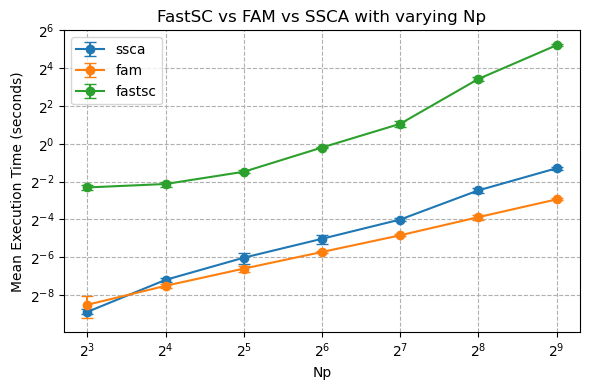

In [2]:
test.plot_benchmark(df, param_name='Np', title="FastSC vs FAM vs SSCA with varying Np", xlabel="Np", 
                   log_x=True, log_y=True, figsize=(6, 4), save_path=None)

There are also other example speed test files in speed_test_files folder that you can test out. The usage is the same.

### 2. Memory 

```
memory_test(func_lambda, name="algorithm", Np=8, L=2, max_log_2=18, no_of_run=10, fam=True, plot=True)
```

The memory test function is simplier and return the peak usage as we vary N and fix Np. It also returns the standard deviation of the memory used.

In [1]:
from scf_test.algorithm import fam, ssca, Fast_SC
import numpy as np
import scf_test.tests as test

In [2]:
def fast_sc_wrapper(signal, Np=64, conjugate=False, coherence=False):
    if coherence:
        opt = {"abs": 0, "calib": 1, "coh": 1}
    else:
        opt = {"abs": 0, "calib": 1, "coh": 0}

    Sx, alpha, f, _, _, _ = Fast_SC(signal, Nw=Np, alpha_max=0.5, Fs=1, opt=opt)

    return np.abs(Sx), f, alpha

In [3]:
fam_peak_usage_8, fam_standard_deviation_8, length = test.memory_test(fam, name="FAM", fam=True,plot=False)
fam_peak_usage_32, fam_standard_deviation_32, length = test.memory_test(fam, name="FAM", fam=True, Np=32, L=8, plot=False)
fam_peak_usage_128, fam_standard_deviation_128, length = test.memory_test(fam, name="FAM", fam=True, Np=128, L=32, plot=False)

ssca_peak_usage_8, ssca_standard_deviation_8, length = test.memory_test(ssca, name="SSCA", plot=False)
ssca_peak_usage_32, ssca_standard_deviation_32, length = test.memory_test(ssca, name="SSCA", Np=32, plot=False)
ssca_peak_usage_128, ssca_standard_deviation_128, length = test.memory_test(ssca, name="SSCA", Np=128, plot=False)

fastsc_peak_usage_8, fastsc_standard_deviation_8, length = test.memory_test(fast_sc_wrapper, name="FastSC", plot=False)
fastsc_peak_usage_32, fastsc_standard_deviation_32, length = test.memory_test(fast_sc_wrapper, name="FastSC", Np=32, plot=False)
fastsc_peak_usage_128, fastsc_standard_deviation_128, length = test.memory_test(fast_sc_wrapper, name="FastSC", Np=128, plot=False)

We don't have a function for plotting but it should be simple to do with matplotlib

In [4]:
import matplotlib.pyplot as plt

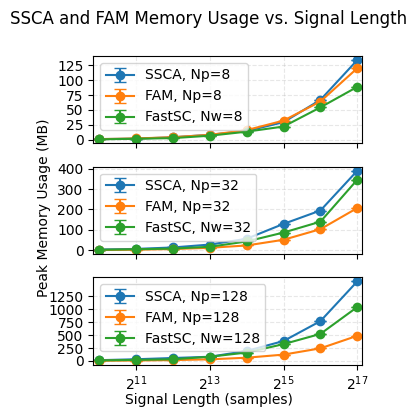

In [5]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(3.5, 4), sharex=True)
plt.suptitle('SSCA and FAM Memory Usage vs. Signal Length', y=0.995)
fig.text(0.5, 0.01, 'Signal Length (samples)', ha='center')
fig.text(0.01, 0.5, 'Peak Memory Usage (MB)', va='center', rotation='vertical')

axes[0].errorbar(length, ssca_peak_usage_8, yerr=ssca_standard_deviation_8, marker='o', capsize=4, label="SSCA, Np=8")
axes[0].errorbar(length, fam_peak_usage_8, yerr=fam_standard_deviation_8, marker='o', capsize=4, label="FAM, Np=8")
axes[0].errorbar(length, fastsc_peak_usage_8, yerr=fastsc_standard_deviation_8, marker='o', capsize=4, label="FastSC, Nw=8")
axes[0].set_xscale('log', base=2)
axes[0].legend()
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].set_yticks([0, 25, 50, 75, 100, 125])

axes[1].errorbar(length, ssca_peak_usage_32, yerr=ssca_standard_deviation_32, marker='o', capsize=4, label="SSCA, Np=32")
axes[1].errorbar(length, fam_peak_usage_32, yerr=fam_standard_deviation_32, marker='o', capsize=4, label="FAM, Np=32")
axes[1].errorbar(length, fastsc_peak_usage_32, yerr=fastsc_standard_deviation_32, marker='o', capsize=4, label="FastSC, Nw=32")
axes[1].set_xscale('log', base=2)
axes[1].legend()
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].set_yticks([0, 100, 200, 300, 400])

axes[2].errorbar(length, ssca_peak_usage_128, yerr=ssca_standard_deviation_128, marker='o', capsize=4, label="SSCA, Np=128")
axes[2].errorbar(length, fam_peak_usage_128, yerr=fam_standard_deviation_128, marker='o', capsize=4, label="FAM, Np=128")
axes[2].errorbar(length, fastsc_peak_usage_128, yerr=fastsc_standard_deviation_128, marker='o', capsize=4, label="FastSC, Nw=128")
axes[2].set_xscale('log', base=2)
axes[2].set_xlim(length[0] * 0.9, length[-1] * 1.1)
axes[2].legend()
axes[2].grid(True, alpha=0.3, linestyle='--')
axes[2].set_yticks([0, 250, 500, 750, 1000, 1250])

plt.tight_layout()
plt.savefig("fig/memory_test.png")
plt.show()